In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import seaborn as sns
from ase import Atoms
from ase.io import read, write

import warnings
warnings.filterwarnings("ignore")

In [2]:
parent_dir = './models'
experiment_name = '3d_latentspace_larger_encoding'
json_folder = 'CrystalTypeAnalysis'
json_dir = f'{parent_dir}/{experiment_name}/{json_folder}'
loss_file = f'{parent_dir}/{experiment_name}/{json_folder}/losses.json'
reconstruction_file = f'{parent_dir}/{experiment_name}/{json_folder}/reconstructions.json'


In [3]:
# Read json files and make them into dataframes
with open(loss_file, 'r') as f:
    losses = json.load(f)
df_loss = pd.DataFrame(losses)

with open(reconstruction_file, 'r') as f:
    reconstructions = json.load(f)
df_rec = pd.DataFrame(reconstructions)

In [4]:
df_loss.head()

,total,cell_parameters,cell_positions,cell_atoms,kld,crystalType
0,-6.720519,0.001038,0.000035,0.000101,0.052114,RheniumTrioxide
1,-3.389564,0.025000,0.000133,0.002174,0.422077,Wurtzite
2,-0.675707,0.204473,0.000006,0.235720,0.289642,CaesiumChloride
3,-6.378380,0.001447,0.000031,0.000160,0.071477,RheniumTrioxide
4,-7.078076,0.000745,0.000015,0.000066,0.042742,RheniumTrioxide


In [5]:
df_rec.head()

,crystalType,n_atoms,n_oxygens,n_metals,cell_parameters,cell_positions,cell_atoms,latent_space_mean,latent_space_std
0,RheniumTrioxide,4,3,1,"[3.8122196197509766, 3.8244056701660156, 3.850...","[[-0.012191645801067352, 0.019514966756105423,...","[2, 1, 1, 1]","[22.777021408081055, -31.239181518554688, 32.8...","[2.851775646209717, -0.8784637451171875, -0.27..."
1,Wurtzite,4,2,2,"[3.292830228805542, 3.3031697273254395, 5.2996...","[[0.29246851801872253, 0.5666155815124512, 0.0...","[2, 2, 1, 1]","[11.552201271057129, -16.68852424621582, 9.451...","[1.9876564741134644, -0.6428550481796265, -0.7..."
2,CaesiumChloride,6,4,2,"[4.669301986694336, 4.700162410736084, 2.94277...","[[-0.01537901908159256, -2.3733824491500854e-0...","[2, 2, 1, 1, 1, 1]","[47.67346954345703, -55.33186721801758, 114.03...","[5.906260967254639, 2.5058209896087646, 6.2513..."
3,RheniumTrioxide,4,3,1,"[3.789325475692749, 3.8126797676086426, 3.8407...","[[-0.017731472849845886, -0.004410471767187118...","[2, 1, 1, 1]","[25.683923721313477, -31.548452377319336, 32.3...","[5.456399440765381, 0.3422107398509979, 1.3401..."
4,RheniumTrioxide,4,3,1,"[3.8302161693573, 3.841684341430664, 3.8687822...","[[-0.010796479880809784, 0.016752008348703384,...","[2, 1, 1, 1]","[22.145906448364258, -30.227371215820312, 32.3...","[2.7149367332458496, -1.03098726272583, -0.356..."


In [6]:
# # Make a cif file from all the reconstructions
# for crystal_type in df_rec['crystalType'].unique():
#     print(crystal_type)
#     df_crystal = df_rec[df_rec['crystalType'] == crystal_type]
#     cell_pos = []
#     cell_atom = []
#     for i, row in df_crystal.iterrows():
#         if i == 0:
#             cell_params=row['cell_parameters']
#         cell_pos.extend(row['cell_positions'])
#         cell_atom.extend(row['cell_atoms'])
#     atoms = Atoms(cell_atom, positions=cell_pos, cell=cell_params)
#     write(f'{parent_dir}/{experiment_name}/{json_folder}/{crystal_type}.cif', atoms)

In [7]:
# Calculate the mean and std of the losses for each crystalType
df_loss_mean = df_loss.groupby('crystalType').mean()
df_loss_std = df_loss.groupby('crystalType').std()

# Calculate the mean and std of n_atoms, n_oxygens and n_metals for each crystalType
df_rec_mean = df_rec[['n_atoms', 'n_oxygens', 'n_metals', 'crystalType']].groupby('crystalType').mean()
df_rec_std = df_rec[['n_atoms', 'n_oxygens', 'n_metals', 'crystalType']].groupby('crystalType').std()

In [8]:
df_combined = pd.concat([df_rec[['n_atoms', 'n_oxygens', 'n_metals', 'crystalType']], df_loss[['total']]], axis=1)
df_combined.head()

,n_atoms,n_oxygens,n_metals,crystalType,total
0,4,3,1,RheniumTrioxide,-6.720519
1,4,2,2,Wurtzite,-3.389564
2,6,4,2,CaesiumChloride,-0.675707
3,4,3,1,RheniumTrioxide,-6.378380
4,4,3,1,RheniumTrioxide,-7.078076


In [9]:
# Show the mean of the losses for each crystalType
df_loss_mean

,total,cell_parameters,cell_positions,cell_atoms,kld
crystalType,,,,,
AntiFluorite,-3.192929,0.095237,0.006125,0.131014,0.442997
CadmiumChloride,-6.124069,0.212860,0.001782,0.076734,0.441325
CadmiumIodide,-5.805180,0.051261,0.001167,0.025291,0.236951
CaesiumChloride,-5.183901,0.209480,0.000369,0.080555,0.295517
Fluorite,-5.940710,0.005594,0.000431,0.006885,0.077744
NickelArsenide,-6.914784,0.018614,0.000823,0.015636,0.163081
RheniumTrioxide,-7.014304,0.002202,0.000157,0.002658,0.046470
RockSalt,-5.046002,0.029153,0.005011,0.022457,0.186322
Rutile,-6.624496,0.009759,0.000791,0.018265,0.128811


In [10]:
# Show the std of the losses for each crystalType
df_loss_std

,total,cell_parameters,cell_positions,cell_atoms,kld
crystalType,,,,,
AntiFluorite,2.554593,0.205130,0.010885,0.261158,0.457055
CadmiumChloride,3.549337,0.548882,0.004751,0.214593,1.405182
CadmiumIodide,2.778338,0.211449,0.002259,0.055176,0.601763
CaesiumChloride,3.138321,0.682243,0.001080,0.248354,0.401445
Fluorite,1.699365,0.014204,0.000771,0.017005,0.138872
NickelArsenide,2.361487,0.064574,0.002077,0.080112,0.370292
RheniumTrioxide,1.173951,0.007458,0.000553,0.012486,0.057052
RockSalt,2.426821,0.095278,0.005810,0.055367,0.153939
Rutile,2.135652,0.024915,0.002022,0.068728,0.270147


In [11]:
df_rec_mean

,n_atoms,n_oxygens,n_metals
crystalType,,,
AntiFluorite,12.962963,5.851852,7.111111
CadmiumChloride,8.692308,5.576923,3.115385
CadmiumIodide,3.851852,2.296296,1.555556
CaesiumChloride,5.846154,3.192308,2.653846
Fluorite,11.846154,7.846154,4.000000
NickelArsenide,4.296296,2.074074,2.222222
RheniumTrioxide,4.076923,3.038462,1.038462
RockSalt,9.115385,4.807692,4.307692
Rutile,6.370370,4.222222,2.148148


In [12]:
df_rec_std

,n_atoms,n_oxygens,n_metals
crystalType,,,
AntiFluorite,8.864282,7.009355,2.750291
CadmiumChloride,1.517082,1.137474,1.032547
CadmiumIodide,2.381074,1.203035,1.450022
CaesiumChloride,10.861647,6.229088,4.740821
Fluorite,0.784465,0.784465,0.000000
NickelArsenide,1.539601,0.384900,1.154701
RheniumTrioxide,0.392232,0.196116,0.196116
RockSalt,1.796150,1.600481,1.086986
Rutile,1.244933,0.847319,0.533761


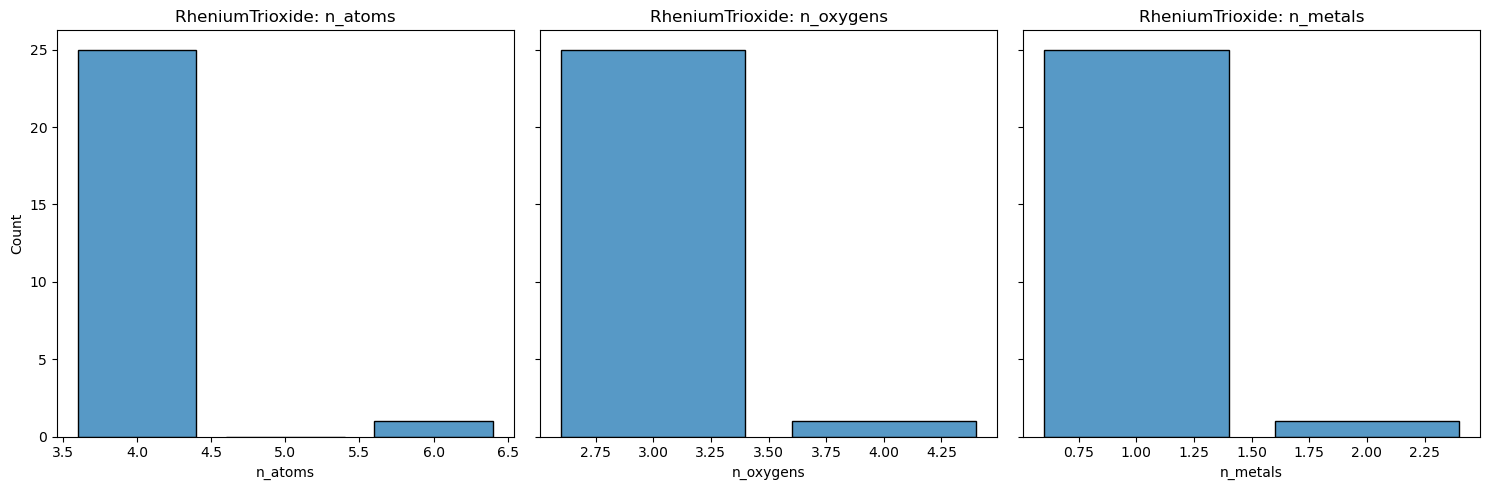

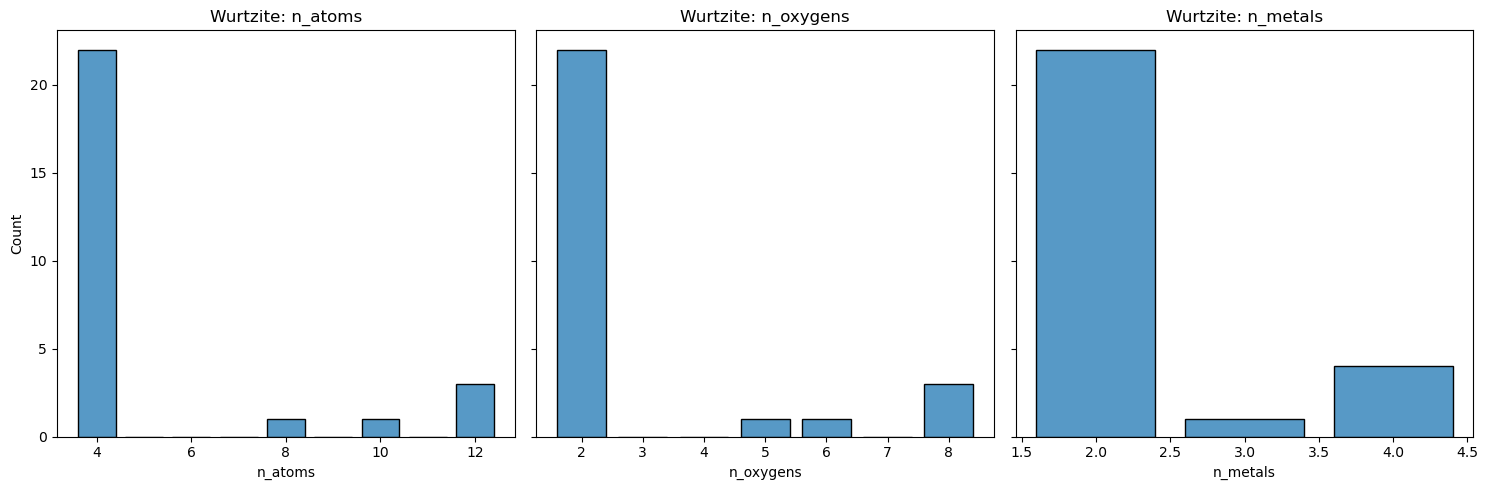

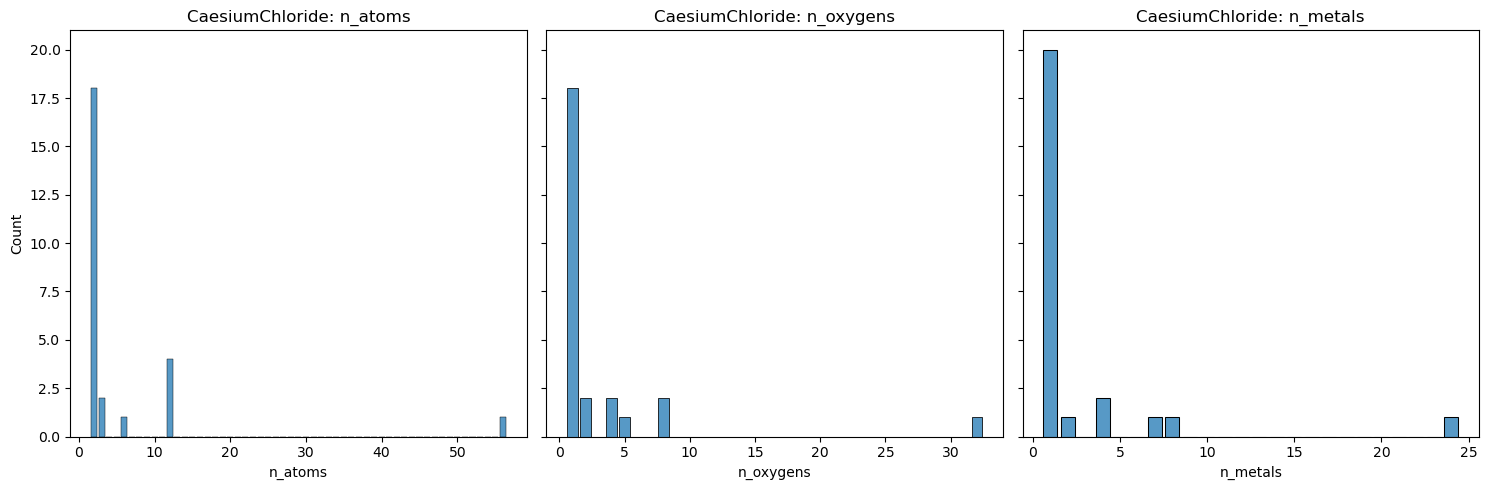

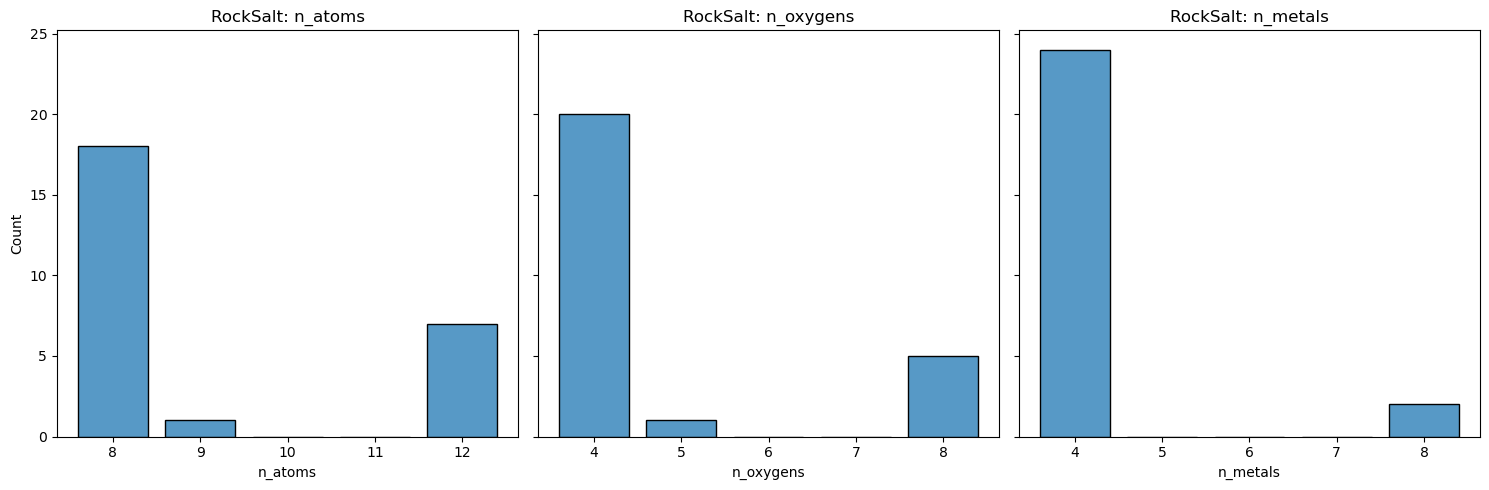

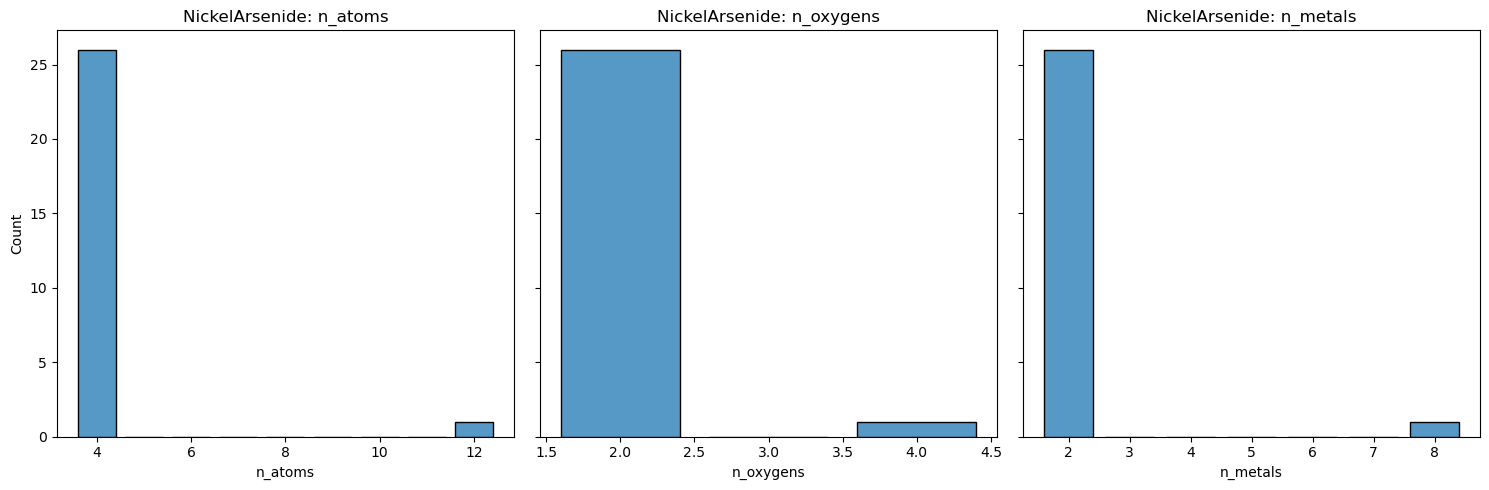

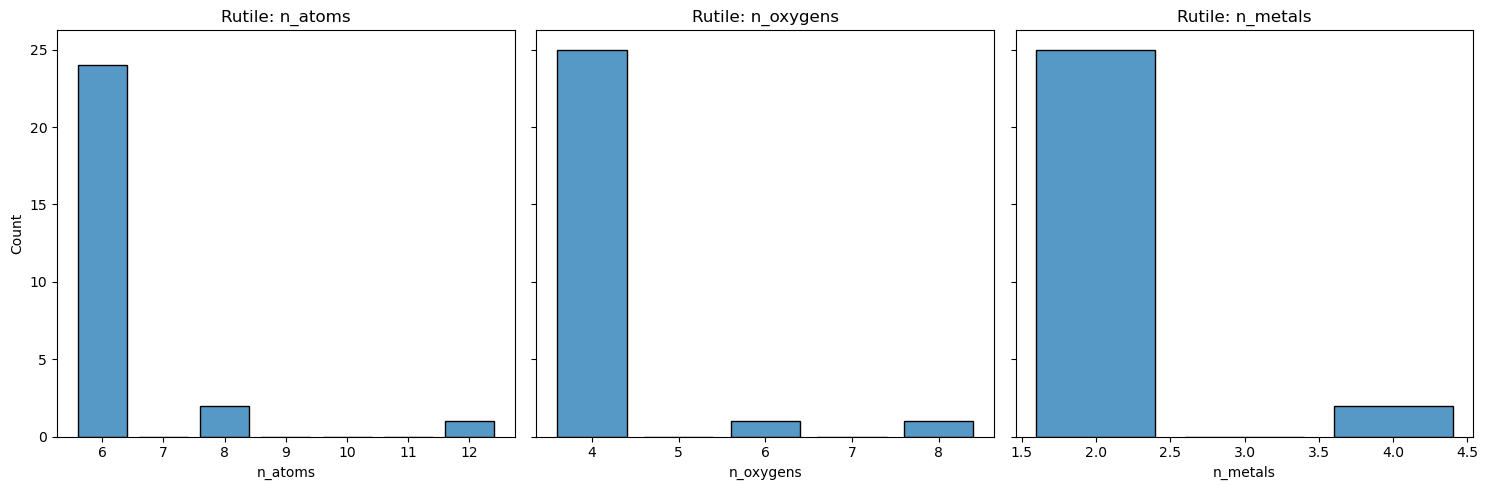

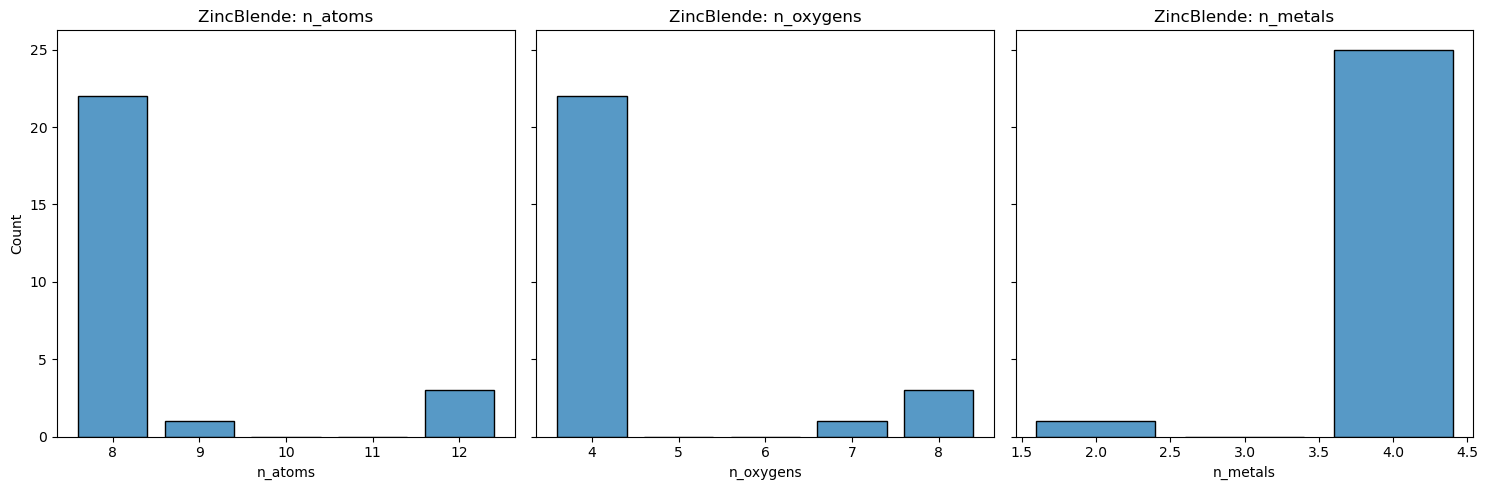

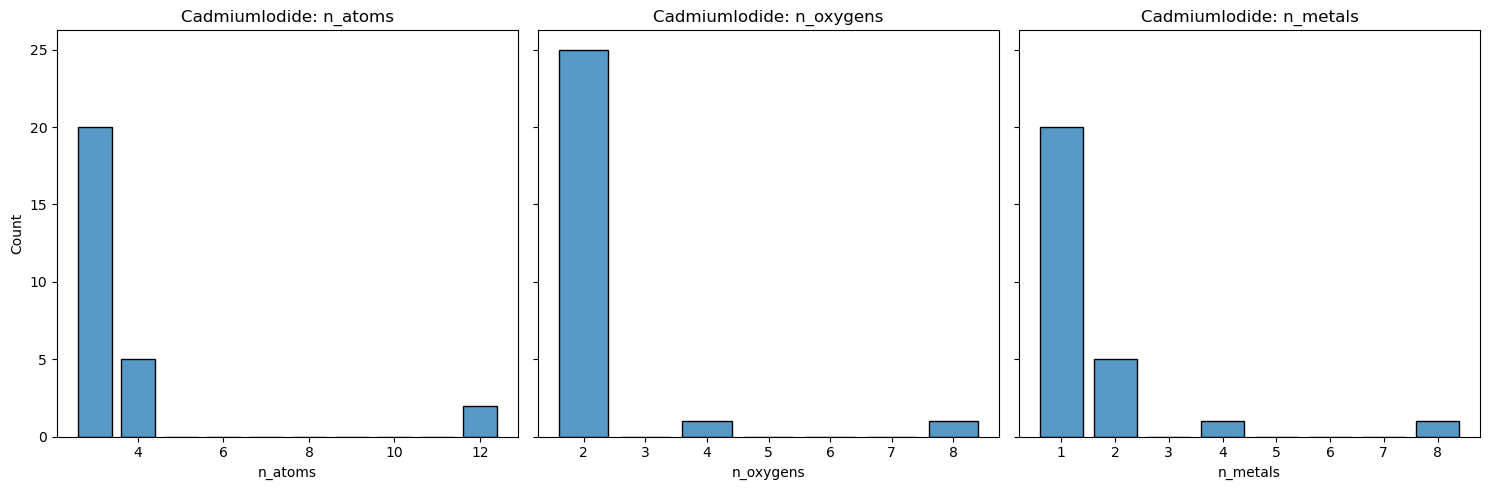

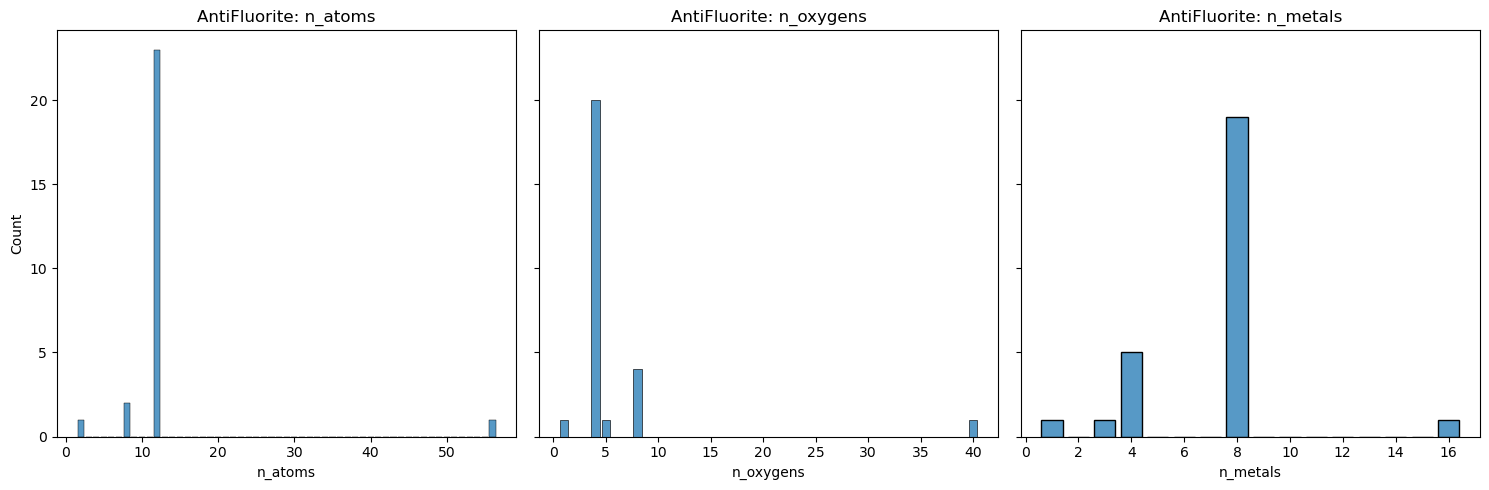

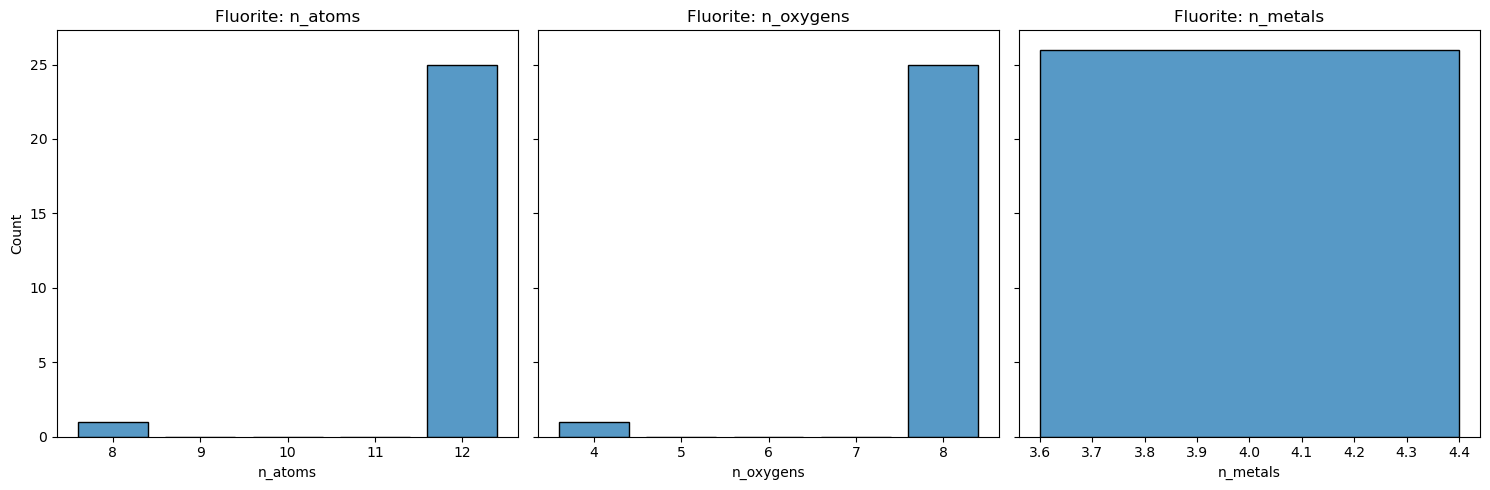

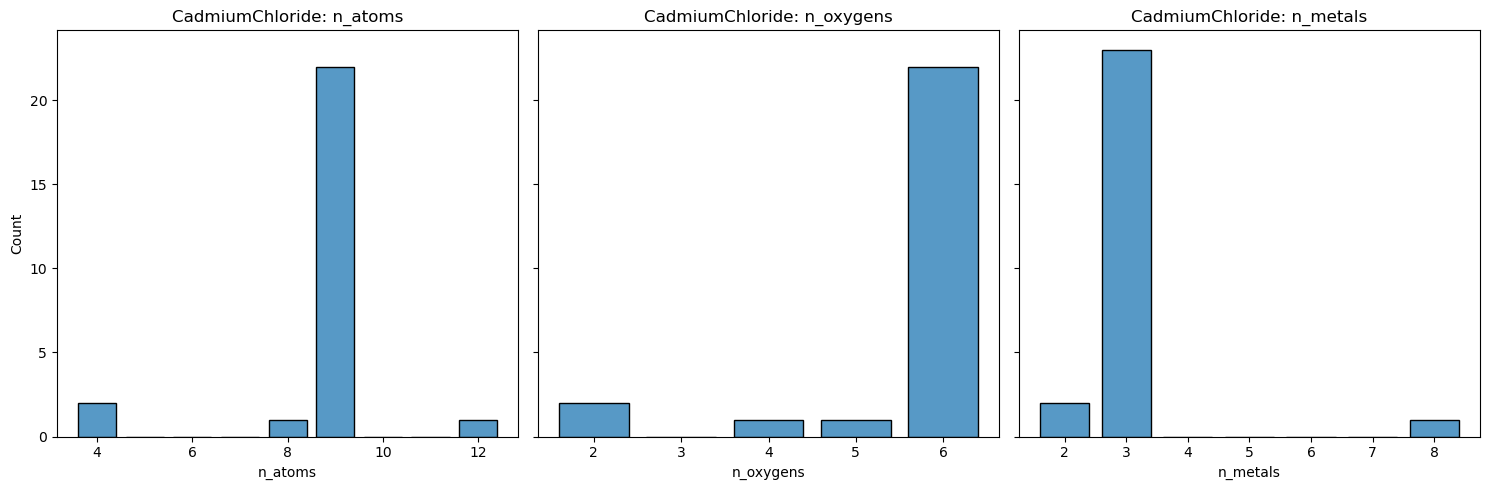

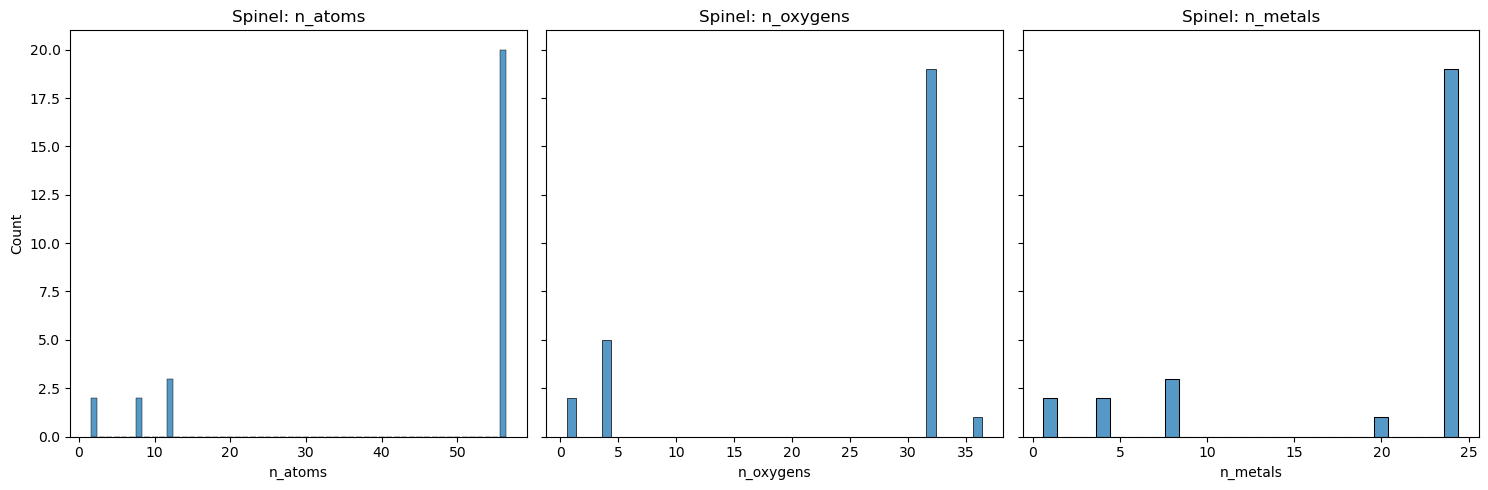

In [13]:
# Plot histogram of n_atoms, n_oxygens and n_metals for each crystalType
for crystal_type in df_rec['crystalType'].unique():
    fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    sns.histplot(data=df_combined[df_combined['crystalType'] == crystal_type], x='n_atoms', ax=ax[0], discrete=True, shrink=0.8)
    ax[0].set_title(f'{crystal_type}: n_atoms')
    sns.histplot(data=df_combined[df_combined['crystalType'] == crystal_type], x='n_oxygens', ax=ax[1], discrete=True, shrink=0.8)
    ax[1].set_title(f'{crystal_type}: n_oxygens')
    sns.histplot(data=df_combined[df_combined['crystalType'] == crystal_type], x='n_metals', ax=ax[2], discrete=True, shrink=0.8)
    ax[2].set_title(f'{crystal_type}: n_metals')
    plt.tight_layout()
    plt.show()

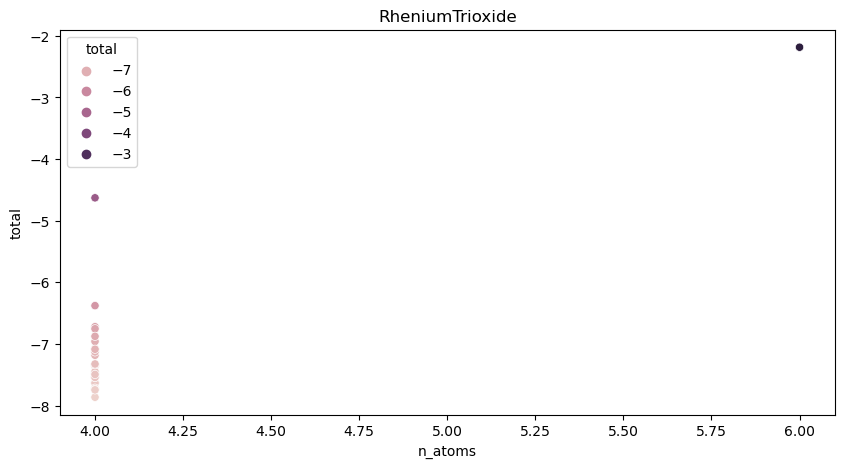

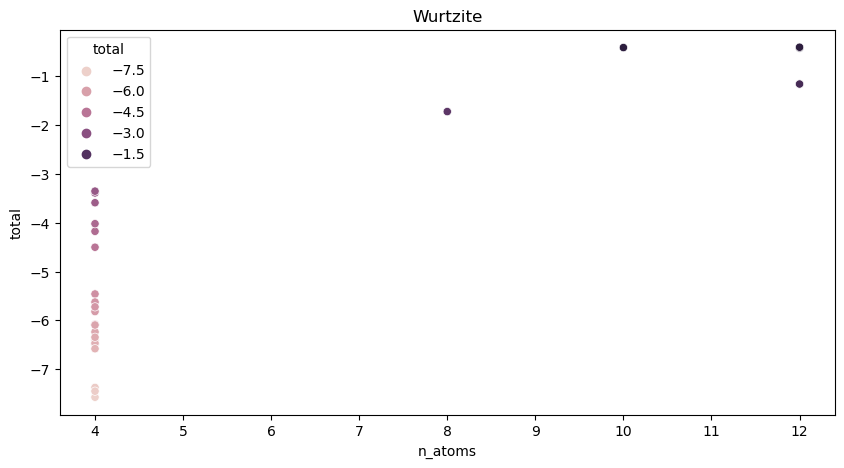

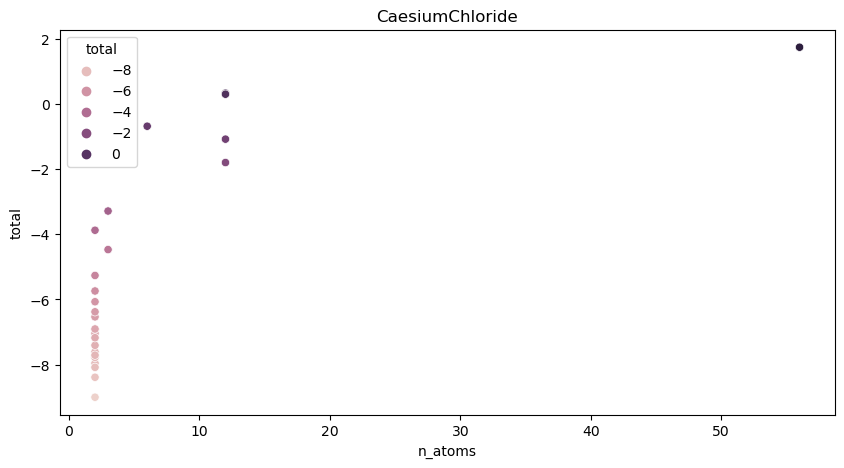

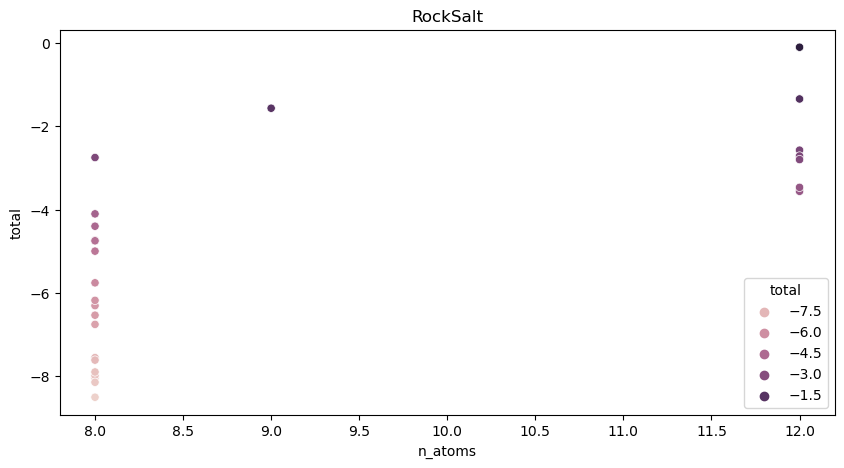

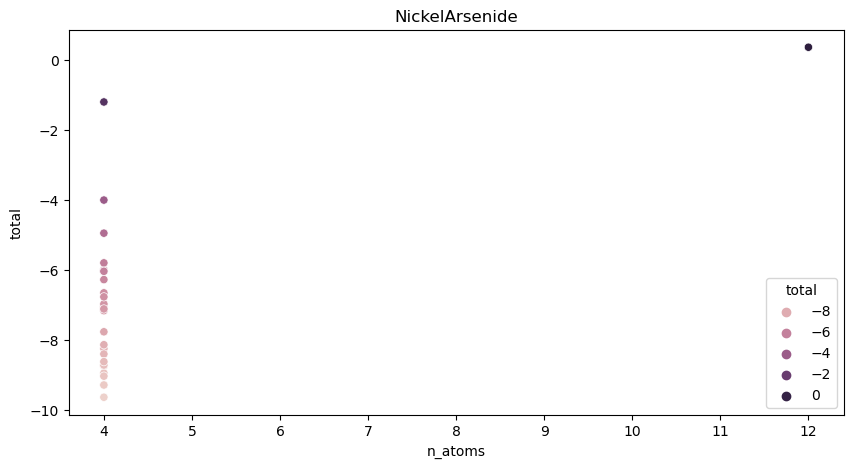

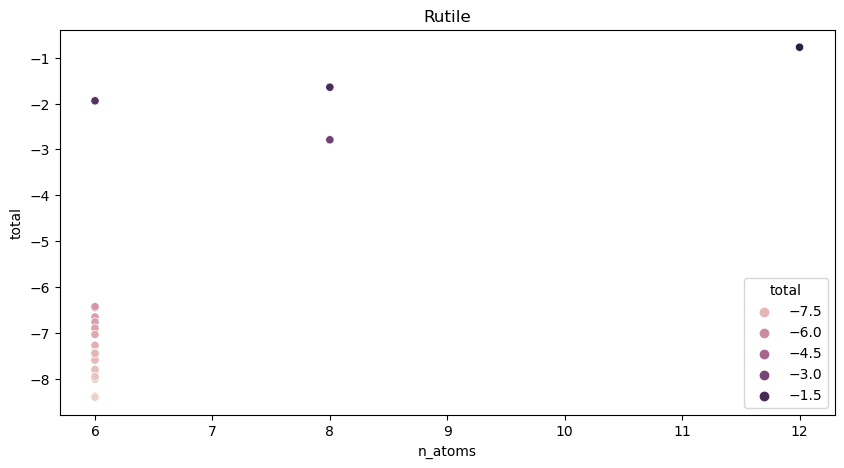

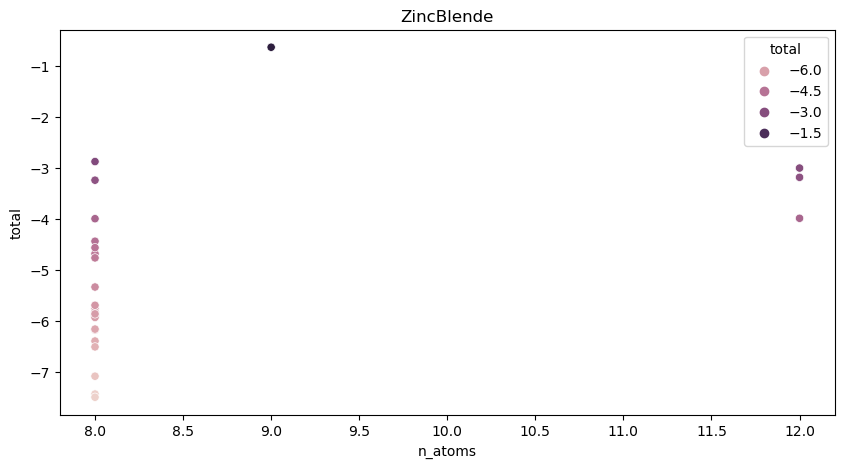

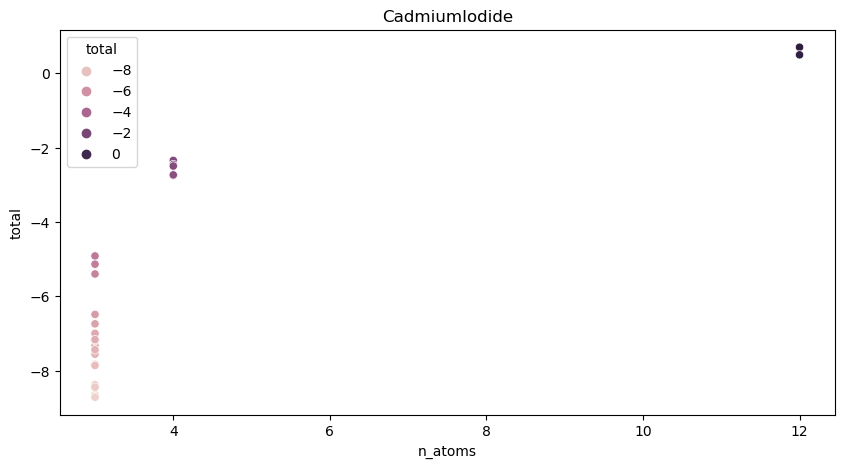

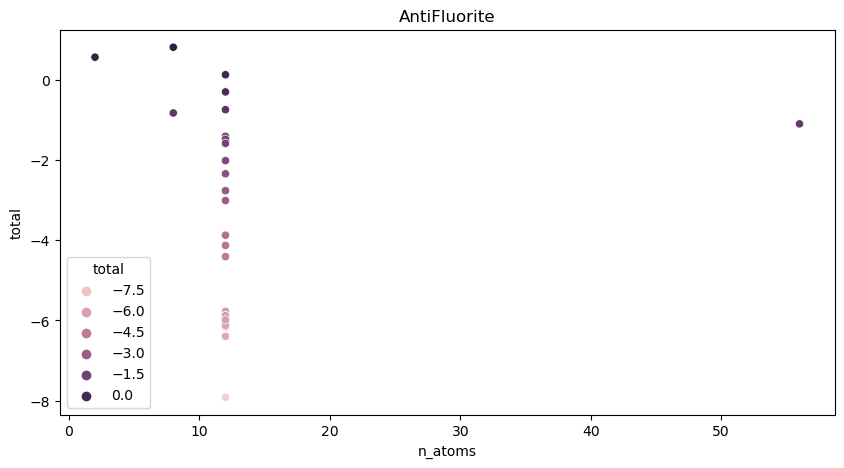

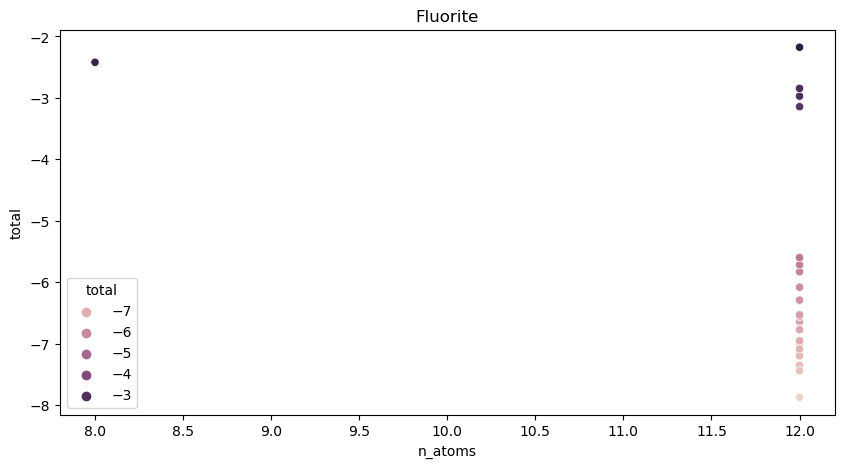

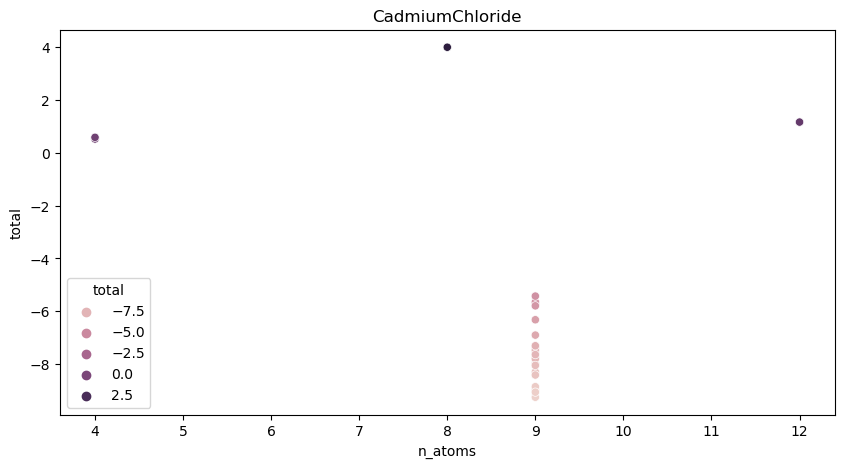

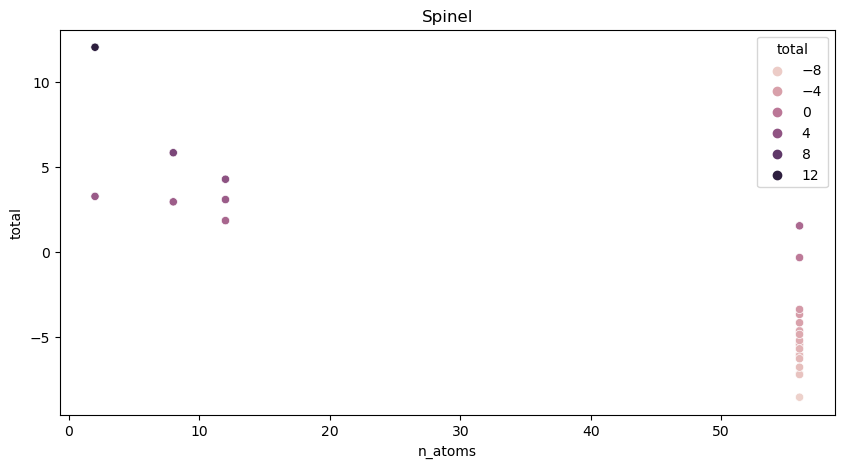

In [14]:
# Plot 2d scatter plot of n_atoms vs total loss for each crystalType
for crystal_type in df_rec['crystalType'].unique():
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=df_combined[df_combined['crystalType'] == crystal_type], x='n_atoms', y='total', hue='total')
    plt.title(f'{crystal_type}')
    plt.show()

In [15]:
import plotly.express as px
import plotly.graph_objects as go

In [32]:
# Plot 3d scatter plot of latent_space_mean from the df_rec dataframe. Each crystalType is represented by a different color and marker type
df_latent = df_rec[['latent_space_mean', 'crystalType']]
latent_space_array = np.array(df_latent['latent_space_mean'].values.tolist())
df_latent[['ls_x', 'ls_y', 'ls_z']] = pd.DataFrame(latent_space_array, index=df_latent.index)
df_latent['loss'] = df_loss['total']

fig = px.scatter_3d(df_latent, x='ls_x', y='ls_y', z='ls_z', color='crystalType', symbol='crystalType', hover_name='crystalType', hover_data=['loss', 'ls_x', 'ls_y', 'ls_z'], color_discrete_sequence=px.colors.qualitative.Dark24)
# fig.update_traces(marker=dict(size=3))
fig.show()
# Save the plot as a html file
fig.write_html(f'{parent_dir}/{experiment_name}/{json_folder}/latent_space.html')